In [2]:
import goes2go
import pandas as pd
import numpy as np
import xarray as xr
from goes2go import GOES
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from tqdm import tqdm

import warnings
warnings.simplefilter("ignore")

import fsspec
fs = fsspec.filesystem('s3', anon=True)
fsspec_caching = {
    "cache_type": "blockcache",  # block cache stores blocks of fixed size and uses eviction using a LRU strategy.
    "block_size": 8
    * 1024
    * 1024,  # size in bytes per block, adjust depends on the file size but the recommended size is in the MB
}

from pyproj import Proj

GOES_EAST_PROJ4 = "+proj=geos +lon_0=-75 +h=35786023 +x_0=0 +y_0=0 +sweep=x +datum=WGS84 +units=m +no_defs"

goes_satellite_height = 35786023  # in meters
goes_satellite_longitude = -75  # in degrees
goes_satellite_latitude = 0  # in degrees

Products to download

- Cloud Height (2 km): ACHA, variable HT
- Cloud Optical Depth (2 km): COD, variable COD
- Cloud Masks (2 km): ACM, variables BCM and ACM
- Cloud Particle Size (2 km): CPS, variables PSD 
- Cloud Top Temperature (2 km): ACHT, variable TEMP
- Cloud Top Phase (2 km): ACTP, variable Phase
- Cloud Pressure (2 km): ACHP, variable PRES

In [3]:
path = './additional-variables/pretraining-test-goes-[2023-2024].csv'
df = pd.read_csv(path)

In [4]:
df.head()

,Unnamed: 0,cloud3d:patch_id,geometry,cloud3d:satellite,geoenrich:admin_countries,geoenrich:elevation,geoenrich:precipitation,geoenrich:temperature,geotiff:stats,majortom:code,...,stac:time_end,tiff:header,internal:current_id,bbox,satellite,_base,date,month,lon,lat
0,43459,20230128002020_2433_2201,b'\x01\x01\x00\x00\x00\xa1\xe8\xf3\xc2\x7f\xe2...,GOES,Cabo Verde,114.46829,2.998448,298.52267,"[array([0.0000000e+00, 3.0517578e-02, 1.466833...",1000km_0000U_0008L,...,2023-01-28 00:29:52.500,"b""LOVE\x01\x00\x00\x02\x00\x00\x00\x02\x00\x00...",43459,"{'xmin': -67.53904794520578, 'ymin': 2.7790048...",GOES,https://data.source.coop/taco/3dclouds/pretrai...,2023-01-28 00:20:20.500,2023-01,-67.539048,2.779005
1,30006,20230128012020_2463_1510,b'\x01\x01\x00\x00\x00\x8a\x8bTC9\xa8P\xc0}.q\...,GOES,Ocean/Sea/Lakes,0.00000,0.967983,299.76870,"[array([0.0000000e+00, 3.0517578e-02, 2.235174...",1000km_0001U_0008L,...,2023-01-28 01:29:52.400,"b""LOVE\x01\x00\x00\x02\x00\x00\x00\x02\x00\x00...",30006,"{'xmin': -66.62849505668979, 'ymin': 15.625263...",GOES,https://data.source.coop/taco/3dclouds/pretrai...,2023-01-28 01:20:20.500,2023-01,-66.628495,15.625264
2,22594,20230128025020_1185_730,b'\x01\x01\x00\x00\x00\n\x14\xba\x9d\x94tW\xc0...,GOES,United States,72.73981,1.268297,292.02902,"[array([0.0000000e+00, 6.1035156e-02, 1.280568...",1000km_0003U_0010L,...,2023-01-28 02:59:51.300,"b""LOVE\x01\x00\x00\x02\x00\x00\x00\x02\x00\x00...",22594,"{'xmin': -93.82157080814082, 'ymin': 32.196062...",GOES,https://data.source.coop/taco/3dclouds/pretrai...,2023-01-28 02:50:20.500,2023-01,-93.821571,32.196062
3,32405,20230128034020_3313_1017,b'\x01\x01\x00\x00\x00pG\xc80\xfexG\xc0\xe1\xc...,GOES,Ocean/Sea/Lakes,0.00000,0.778212,296.62750,"[array([0.0000000e+00, 6.1035156e-02, 1.420266...",1000km_0003U_0005L,...,2023-01-28 03:49:52.000,b'LOVE\x01\x00\x00\x02\x00\x00\x00\x02\x00\x00...,32405,"{'xmin': -46.94525728015185, 'ymin': 26.042578...",GOES,https://data.source.coop/taco/3dclouds/pretrai...,2023-01-28 03:40:20.500,2023-01,-46.945257,26.042578
4,25524,20230128042020_2199_1318,b'\x01\x01\x00\x00\x00\xc5[\x13\x1a\xfa\xe3Q\x...,GOES,Greece,143.93806,0.542502,299.62476,"[array([0.0000000e+00, 3.0517578e-02, 1.792796...",1000km_0002U_0008L,...,2023-01-28 04:29:51.300,b'LOVE\x01\x00\x00\x02\x00\x00\x00\x02\x00\x00...,25524,"{'xmin': -71.56214000597454, 'ymin': 19.349829...",GOES,https://data.source.coop/taco/3dclouds/pretrai...,2023-01-28 04:20:20.500,2023-01,-71.562140,19.349829


In [138]:
df_add = pd.read_csv('./additional-variables/pretraining-test-goes-[2023-2024]-with-additional-variables.csv')

In [149]:
len(df_add)

1900

In [134]:
test_file = df.iloc[0]
print(test_file)

Unnamed: 0                                                               43459
cloud3d:patch_id                                      20230128002020_2433_2201
geometry                     b'\x01\x01\x00\x00\x00\xa1\xe8\xf3\xc2\x7f\xe2...
cloud3d:satellite                                                         GOES
geoenrich:admin_countries                                           Cabo Verde
geoenrich:elevation                                                  114.46829
geoenrich:precipitation                                               2.998448
geoenrich:temperature                                                298.52267
geotiff:stats                [array([0.0000000e+00, 3.0517578e-02, 1.466833...
majortom:code                                               1000km_0000U_0008L
stac:crs                     PROJCS["unknown",GEOGCS["unknown",DATUM["Unkno...
stac:geotransform            [312627.1875    2003.96875      0.      819642...
stac:tensor_shape                                   

### Find relevant files for images & additional variables

We need to write a loop around this, since the goes2go searching across long time periods is pretty slow. I also noticed that `goes2go.goes_nearesttime` takes way longer than searching for a timerange.

In [6]:
def check_time_in_range(dt, query_dt, delta_minutes=2):
    start_dt = query_dt - timedelta(minutes=delta_minutes)
    end_dt = query_dt + timedelta(minutes=delta_minutes)
    return start_dt <= dt <= end_dt

def get_correct_file(files, query_dt):
    if len(files) == 0:
        return None
    else:
        files['diff'] = abs(pd.to_datetime(files['start']) - query_dt)
        correct_file = files.loc[files['diff'].idxmin()]
        if check_time_in_range(pd.to_datetime(correct_file['start']), query_dt):
            return correct_file['file']
        else:
            return None

In [7]:
abi_files = goes2go.goes_timerange(
    satellite='noaa-goes16',
    start=pd.to_datetime(test_file['date']) - timedelta(minutes=10), 
    end=pd.to_datetime(test_file['date']) + timedelta(minutes=10),
    download=False,
    domain='F',
    product="ABI-L2-MCMIP",
)

abi_files['diff'] = abs(abi_files['start'] - pd.to_datetime(test_file['date']))

In [8]:
abi_file = get_correct_file(abi_files, pd.to_datetime(test_file['date']))
abi_file

'noaa-goes16/ABI-L2-MCMIPF/2024/059/22/OR_ABI-L2-MCMIPF-M6_G16_s20240592210206_e20240592219527_c20240592220004.nc'

#### Other Data Products

In [ ]:
# Cloud height at 2 km

acha_files = goes2go.goes_timerange(
    satellite='noaa-goes16',
    start=pd.to_datetime(test_file['date']) - timedelta(minutes=10), 
    end=pd.to_datetime(test_file['date']) + timedelta(minutes=10),
    download=False,
    domain='F',
    product="ABI-L2-ACHA2KMF",
)

acha_file = get_correct_file(acha_files, pd.to_datetime(test_file['date']))
acha_file

In [10]:
# Cloud pressure at 2 km

achp_files = goes2go.goes_timerange(
    satellite='noaa-goes16',
    start=pd.to_datetime(test_file['date']) - timedelta(minutes=10), 
    end=pd.to_datetime(test_file['date']) + timedelta(minutes=10),
    download=False,
    # domain='F',
    product="ABI-L2-ACHP2KMF",
)
achp_file = get_correct_file(achp_files, pd.to_datetime(test_file['date']))
achp_file

'noaa-goes16/ABI-L2-ACHP2KMF/2024/059/22/OR_ABI-L2-ACHP2KMF-M6_G16_s20240592210206_e20240592219514_c20240592223123.nc'

In [11]:
# Cloud optical depth at 2 km

cod_files = goes2go.goes_timerange(
    satellite='noaa-goes16',
    start=pd.to_datetime(test_file['date']) - timedelta(minutes=10), 
    end=pd.to_datetime(test_file['date']) + timedelta(minutes=10),
    download=False,
    # domain='F',
    product="ABI-L2-COD2KMF",
)

cod_file = get_correct_file(cod_files, pd.to_datetime(test_file['date']))
cod_file

'noaa-goes16/ABI-L2-COD2KMF/2024/059/22/OR_ABI-L2-COD2KMF-M6_G16_s20240592210206_e20240592219514_c20240592224351.nc'

In [12]:
# Cloud temperature at 2 km

acht_files = goes2go.goes_timerange(
    satellite='noaa-goes16',
    start=pd.to_datetime(test_file['date']) - timedelta(minutes=10), 
    end=pd.to_datetime(test_file['date']) + timedelta(minutes=10),
    download=False,
    # domain='F',
    product="ABI-L2-ACHTF",
)
acht_file = get_correct_file(acht_files, pd.to_datetime(test_file['date']))
acht_file

'noaa-goes16/ABI-L2-ACHTF/2024/059/22/OR_ABI-L2-ACHTF-M6_G16_s20240592210206_e20240592219514_c20240592223121.nc'

In [13]:
# Clear sky mask at 2 km

acm_files = goes2go.goes_timerange(
    satellite='noaa-goes16',
    start=pd.to_datetime(test_file['date']) - timedelta(minutes=10), 
    end=pd.to_datetime(test_file['date']) + timedelta(minutes=10),
    download=False,
    # domain='F',
    product="ABI-L2-ACMF",
)
acm_file = get_correct_file(acm_files, pd.to_datetime(test_file['date']))
acm_file

'noaa-goes16/ABI-L2-ACMF/2024/059/22/OR_ABI-L2-ACMF-M6_G16_s20240592210206_e20240592219514_c20240592220324.nc'

In [14]:
# Cloud phase at 2 km

actp_files = goes2go.goes_timerange(
    satellite='noaa-goes16',
    start=pd.to_datetime(test_file['date']) - timedelta(minutes=10), 
    end=pd.to_datetime(test_file['date']) + timedelta(minutes=10),
    download=False,
    # domain='F',
    product="ABI-L2-ACTPF",
)
actp_file = get_correct_file(actp_files, pd.to_datetime(test_file['date']))
actp_file

'noaa-goes16/ABI-L2-ACTPF/2024/059/22/OR_ABI-L2-ACTPF-M6_G16_s20240592210206_e20240592219514_c20240592221095.nc'

In [155]:
# Cloud particle size at 2 km

cps_files = goes2go.goes_timerange(
    satellite='noaa-goes16',
    start=pd.to_datetime(test_file['date']) - timedelta(minutes=10), 
    end=pd.to_datetime(test_file['date']) + timedelta(minutes=10),
    download=False,
    # domain='F',
    product="ABI-L2-CPSF",
)
cps_file = get_correct_file(cps_files, pd.to_datetime(test_file['date']))
cps_file

'noaa-goes16/ABI-L2-CPSF/2023/028/00/OR_ABI-L2-CPSF-M6_G16_s20230280020205_e20230280029513_c20230280033057.nc'

### Compile summary file for tropical cyclones

In [2]:
tc_all = pd.read_csv('./IBTrACs-filtered/goes_ibtracs.NA-EP.list.v04r01.csv')
tc_all['ISO_TIME'] = pd.to_datetime(tc_all['ISO_TIME'])

<Axes: >

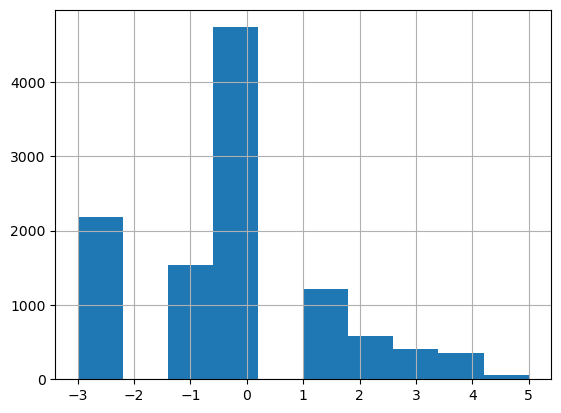

In [3]:
tc_all.USA_SSHS.hist()

In [26]:
df = pd.read_csv('./IBTrACs-filtered/jasmin.goes_ibtracs.NA-EP.list.v04r01.csv')
df['start'] = pd.to_datetime(df['start'])

In [27]:
df_subset = df[df['start'].dt.year.isin([2023, 2024]) & df['start'].dt.day.isin([28, 29, 30, 31])]

In [29]:
df_subset.columns = df_subset.columns.str.lower()

In [30]:
df_subset = df_subset[df_subset['start'].dt.minute.isin([0, 30])]

In [31]:
df_subset.to_csv('pretraining-test-goes-cyclones-[2023-2024].csv', index=False)

### Get example patch

In [16]:
def get_goes_image(
    file: str,)-> xr.Dataset:
    """
    Get the GOES image for a given timestamp.
    
    Args:
        file (str): The path to the GOES image.
    
    Returns:
        xr.Dataset: The GOES dataset for the specified timestamp.
    """
    # Create filesystem object inside worker process to avoid fork-safety issues
    fs = fsspec.filesystem('s3', anon=True)
    fsspec_caching = {
        "cache_type": "blockcache",  # block cache stores blocks of fixed size and uses eviction using a LRU strategy.
        "block_size": 8 * 1024 * 1024 # size in bytes per block, adjust depends on the file size but the recommended size is in the MB}
    }
    ds = xr.open_dataset(fs.open(file, **fsspec_caching), engine="h5netcdf")
    return ds

def get_goes_patch(
    lat: float, lon: float, dataset: xr.Dataset, patch_size: int
) -> xr.Dataset:
    """
    Get a patch of GOES data centered around a given latitude and longitude.
    """
    x, y = get_abi_x_y(np.array([lat]), np.array([lon]), dataset)
    x_dif = dataset.x.diff('x').values[0]
    y_dif = dataset.y.diff('y').values[0]
    return dataset.sel(
       x=slice(x[0] - (abs(x_dif) * patch_size / 2), x[0] + (abs(x_dif) * patch_size / 2)),
      y=slice(y[0] + (abs(y_dif) * patch_size / 2), y[0] - (abs(y_dif) * patch_size / 2)),
    )

def get_abi_x_y(
    lat: np.ndarray, lon: np.ndarray, dataset: xr.Dataset
) -> tuple[np.ndarray, np.ndarray]:
    """
    Get the x, y coordinates in the ABI projection for given latitudes and
        longitudes
    """
    p = get_abi_proj(dataset)
    x, y = p(lon, lat)
    return (
        x / dataset.goes_imager_projection.perspective_point_height,
        y / dataset.goes_imager_projection.perspective_point_height,
    )

def get_abi_proj(dataset: xr.Dataset) -> Proj:
    """
    Return a pyproj projection from the information contained within an ABI file
    """
    return Proj(
        proj="geos",
        h=dataset.goes_imager_projection.perspective_point_height,
        lon_0=dataset.goes_imager_projection.longitude_of_projection_origin,
        lat_0=dataset.goes_imager_projection.latitude_of_projection_origin,
        sweep=dataset.goes_imager_projection.sweep_angle_axis,
    )

In [108]:
ds = get_goes_image(file=abi_file)

In [109]:
lat = test_file['lat']
lon = test_file['lon']

ds_patch = get_goes_patch(lat, lon, ds, 256)

In [110]:
ds_patch.CMI_C01.valid_range

array([   0, 4095], dtype=int16)

In [157]:
file_ = cps_file

ds_ = get_goes_image(file=file_)
lat = test_file['lat']
lon = test_file['lon']

ds_patch_ = get_goes_patch(lat, lon, ds_, 256)

In [ ]:
ds_patch_['CPS']

### Investigate Patches

In [4]:
from glob import glob
files = glob('/home/users/annaju/data/cyclones/goes-16/*.nc')

In [5]:
n = np.random.randint(0, len(files))
# n = 390
print(f"{n}: {files[n]}")

ds_test = xr.open_dataset(files[n], engine='h5netcdf')

1770: /home/users/annaju/data/cyclones/goes-16/20230629190020_2023180N13264_[+14.910deg_-99.138deg]_patch.nc


In [15]:
np.unique(ds_test.particle_size_DQF.values)

array([ 0, 14], dtype=int8)

In [46]:
ds_test.pressure_DQF

<xarray.DataArray 'pressure_DQF' (y: 256, x: 256)> Size: 66kB
[65536 values with dtype=int8]
Coordinates:
    t        datetime64[ns] 8B ...
  * y        (y) float32 1kB 0.05172 0.05166 0.0516 ... 0.03755 0.03749 0.03744
  * x        (x) float32 1kB -0.07596 -0.07591 -0.07585 ... -0.06174 -0.06168
Attributes: (12/14)
    long_name:                       ABI L2+ Cloud Top Pressure data quality ...
    standard_name:                   status_flag
    valid_range:                     [0 3]
    units:                           1
    flag_values:                     [0 1 2 3 4]
    flag_meanings:                   good_quality_qf marginal_quality_qf retr...
    ...                              ...
    cell_methods:                    local_zenith_angle: point solar_zenith_a...
    percent_good_quality_qf:         0.5533275
    percent_marginal_quality_qf:     0.012775807
    percent_retrieval_attempted_qf:  0.0031000974
    percent_bad_quality_qf:          0.44180876
    percent_opaque_retrieval_qf:     0.0